# Portafolio Actuarial — Proyecto 03
## Modelo GLM para Tarifación de Seguros de Gastos Médicos

**Objetivo:** estimar la prima pura de cada asegurado usando un GLM Tweedie,
produciendo relatividades de riesgo interpretables para el equipo de pricing.

| Herramienta | Uso |
|---|---|
| `pandas` | Manipulación del dataset |
| `matplotlib` / `seaborn` | Visualización |
| `statsmodels` | Ajuste del GLM Tweedie |
| `scikit-learn` | Validación cruzada |
| `scipy` | Pruebas estadísticas |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
from sklearn.linear_model import TweedieRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from scipy import stats

warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#F8F9FA',
    'figure.facecolor': 'white',
    'font.family': 'sans-serif',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#2C3E50',
})
AZUL = '#4A7FC1'
ROJO = '#C0392B'
VERDE = '#27AE60'
print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


In [ ]:
#Conección a google drive para usar el archivo csv subido a dicha plataforma
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga y exploración inicial del dataset


In [ ]:
#Lectura inicial del DF:
#------------------------------------------------------------------------------
# 1. Carga mediante pandas.read_csv
# 2. Lectura de tamaño mediante .shape de numpy
# 3. Impresión de los tipos de datos con .dtypes de numpy
# 4. Lectura de las primeras 5 filas mediante .head de pandas
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/gastos medicos.csv')
print(f'Dimensiones: {df.shape}')
print(f'\nTipos de dato:')
print(df.dtypes)
df.head()


Dimensiones: (10000, 11)

Tipos de dato:
id_poliza            object
edad                  int64
sexo                 object
imc                 float64
fumador               int64
region               object
num_dependientes      int64
tipo_plan            object
deducible            object
exposicion          float64
prima_pura          float64
dtype: object


,id_poliza,edad,sexo,imc,fumador,region,num_dependientes,tipo_plan,deducible,exposicion,prima_pura
0,P00001,23,M,35.4,0,Norte,4,Familiar,Alto,0.9897,27648.56
1,P00002,62,F,37.2,1,Centro,2,Familiar,Alto,0.4099,0.00
2,P00003,55,F,29.3,1,Norte,3,Familiar,Medio,0.7622,0.00
3,P00004,43,M,20.7,0,Occidente,4,Familiar,Bajo,0.3287,0.00
4,P00005,42,M,37.2,0,Centro,2,Familiar,Alto,0.7974,0.00


In [ ]:
#Estadistica descriptiva
#------------------------------------------------------------------------------
#Revisión de datos estadisticos basicos con .describe de pandas redondeando a 2 decimales
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
print(df.describe().round(2))


=== ESTADÍSTICAS DESCRIPTIVAS ===
           edad       imc   fumador  num_dependientes  exposicion  prima_pura
count  10000.00  10000.00  10000.00          10000.00    10000.00    10000.00
mean      45.79     27.71      0.22              1.98        0.63     1554.25
std       16.38      5.41      0.41              1.41        0.22     5798.36
min       18.00     16.00      0.00              0.00        0.25        0.00
25%       32.00     24.00      0.00              1.00        0.44        0.00
50%       46.00     27.65      0.00              2.00        0.63        0.00
75%       60.00     31.40      0.00              3.00        0.81        0.00
max       74.00     47.10      1.00              4.00        1.00    98713.49


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Distribución de la variable objetivo

La prima pura debe mostrar masa en cero (pólizas sin siniestros) y cola derecha
pesada — las características que hacen a la distribución Tweedie la elección correcta.


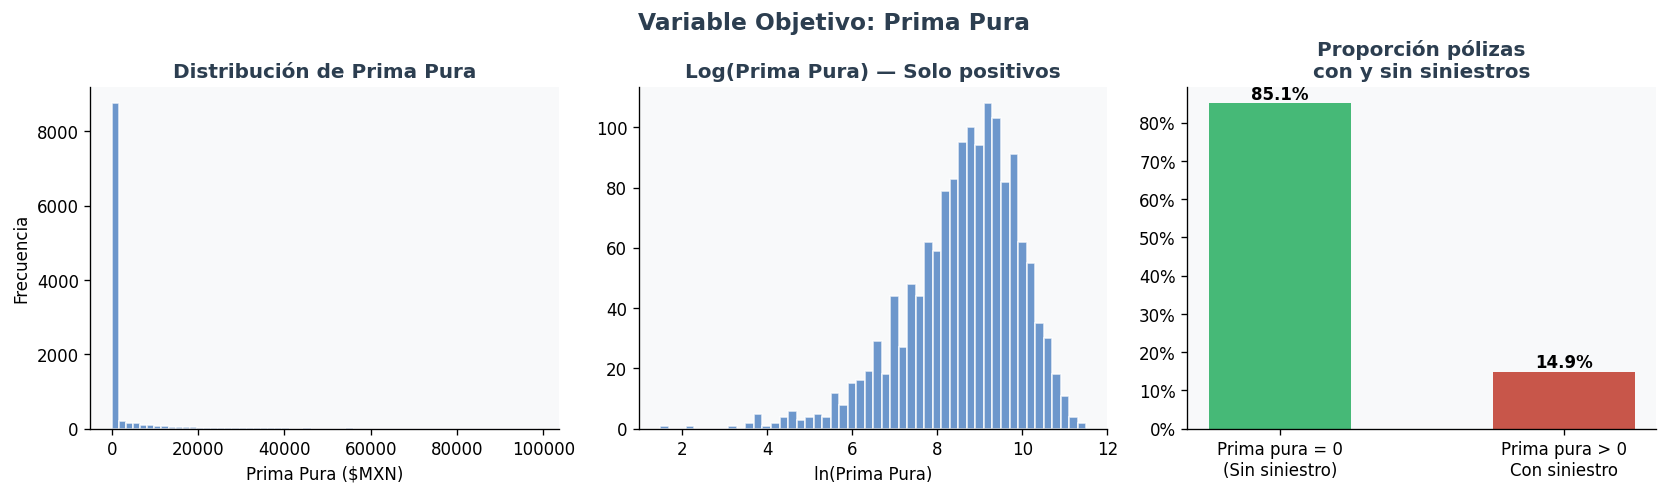

Masa en cero: 85.1%
Media: $1,554
Mediana: $0
Asimetría: 5.92
Estos datos indican como la distribución tweedy es la mas optima para modelar la variable objetivo.


In [ ]:
#Graficos descriptivos
#------------------------------------------------------------------------------


#Arreglo de los graficos y su tamaño
#------------------------------------------------------------------------------
#Para el caso se tiene un arreglo de una fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

#Descripción del codigo
# axes[i] indica el grafico que se modifica, al ser una unica fila solo se requiere un parametro

# Distribución completa mediante histograma con 60 columnas en color azul con trasparencia al 0.8 y limite de barra color blanco
#------------------------------------------------------------------------------
axes[0].hist(df['prima_pura'], bins=60, color=AZUL, alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución de Prima Pura')
axes[0].set_xlabel('Prima Pura ($MXN)')
axes[0].set_ylabel('Frecuencia')

# Solo valores positivos (log-escala):
#------------------------------------------------------------------------------
# Se  grafica e logaritimo para estabilizar la distribución y maginificar valores muy pequeños
# asi como reducir peso de los valores muy grandes haciendo mas simetrica la distribución.
# Se agrega 1 a el logaritmo para evitar ln(0) o valores muy aproximados a esto.
positivos = df[df['prima_pura'] > 0]['prima_pura']
axes[1].hist(np.log(positivos + 1), bins=50, color=AZUL, alpha=0.8, edgecolor='white')
axes[1].set_title('Log(Prima Pura) — Solo positivos')
axes[1].set_xlabel('ln(Prima Pura)')

# Proporción ceros vs positivos
#------------------------------------------------------------------------------
#Se separa en dos grupos las primas iguales a 0 y las que son mayores a 0
prop = [( df['prima_pura'] == 0).mean(), (df['prima_pura'] > 0).mean()]
axes[2].bar(['Prima pura = 0\n(Sin siniestro)', 'Prima pura > 0\nCon siniestro'],
            prop, color=[VERDE, ROJO], alpha=0.85, width=0.5)
axes[2].set_title('Proporción pólizas\ncon y sin siniestros')
#Se ajusta el eje Y para valores de 0 a 1
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
#se cicla el vector de barras para añadir un texto con el valor porcentual de dicha barra,
# i,v son las coordenadas, a v se lse suma 0.01 para tener espacio entre el texto y la barra.
for i, v in enumerate(prop):
    axes[2].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

#Titulo de la matriz de graficos y sus parametros
#------------------------------------------------------------------------------
plt.tight_layout()
plt.suptitle('Variable Objetivo: Prima Pura', y=1.02, fontsize=14,
             fontweight='bold', color='#2C3E50')
plt.show()

#Estadisticas utiles para EDA
#------------------------------------------------------------------------------
print(f'Masa en cero: {(df.prima_pura==0).mean():.1%}')
print(f'Media: ${df.prima_pura.mean():,.0f}')
print(f'Mediana: ${df.prima_pura.median():,.0f}')
print(f'Asimetría: {df.prima_pura.skew():.2f}')
print('Estos datos indican como la distribución tweedy es la mas optima para modelar la variable objetivo.')

### 2.2 Prima pura por variable categórica


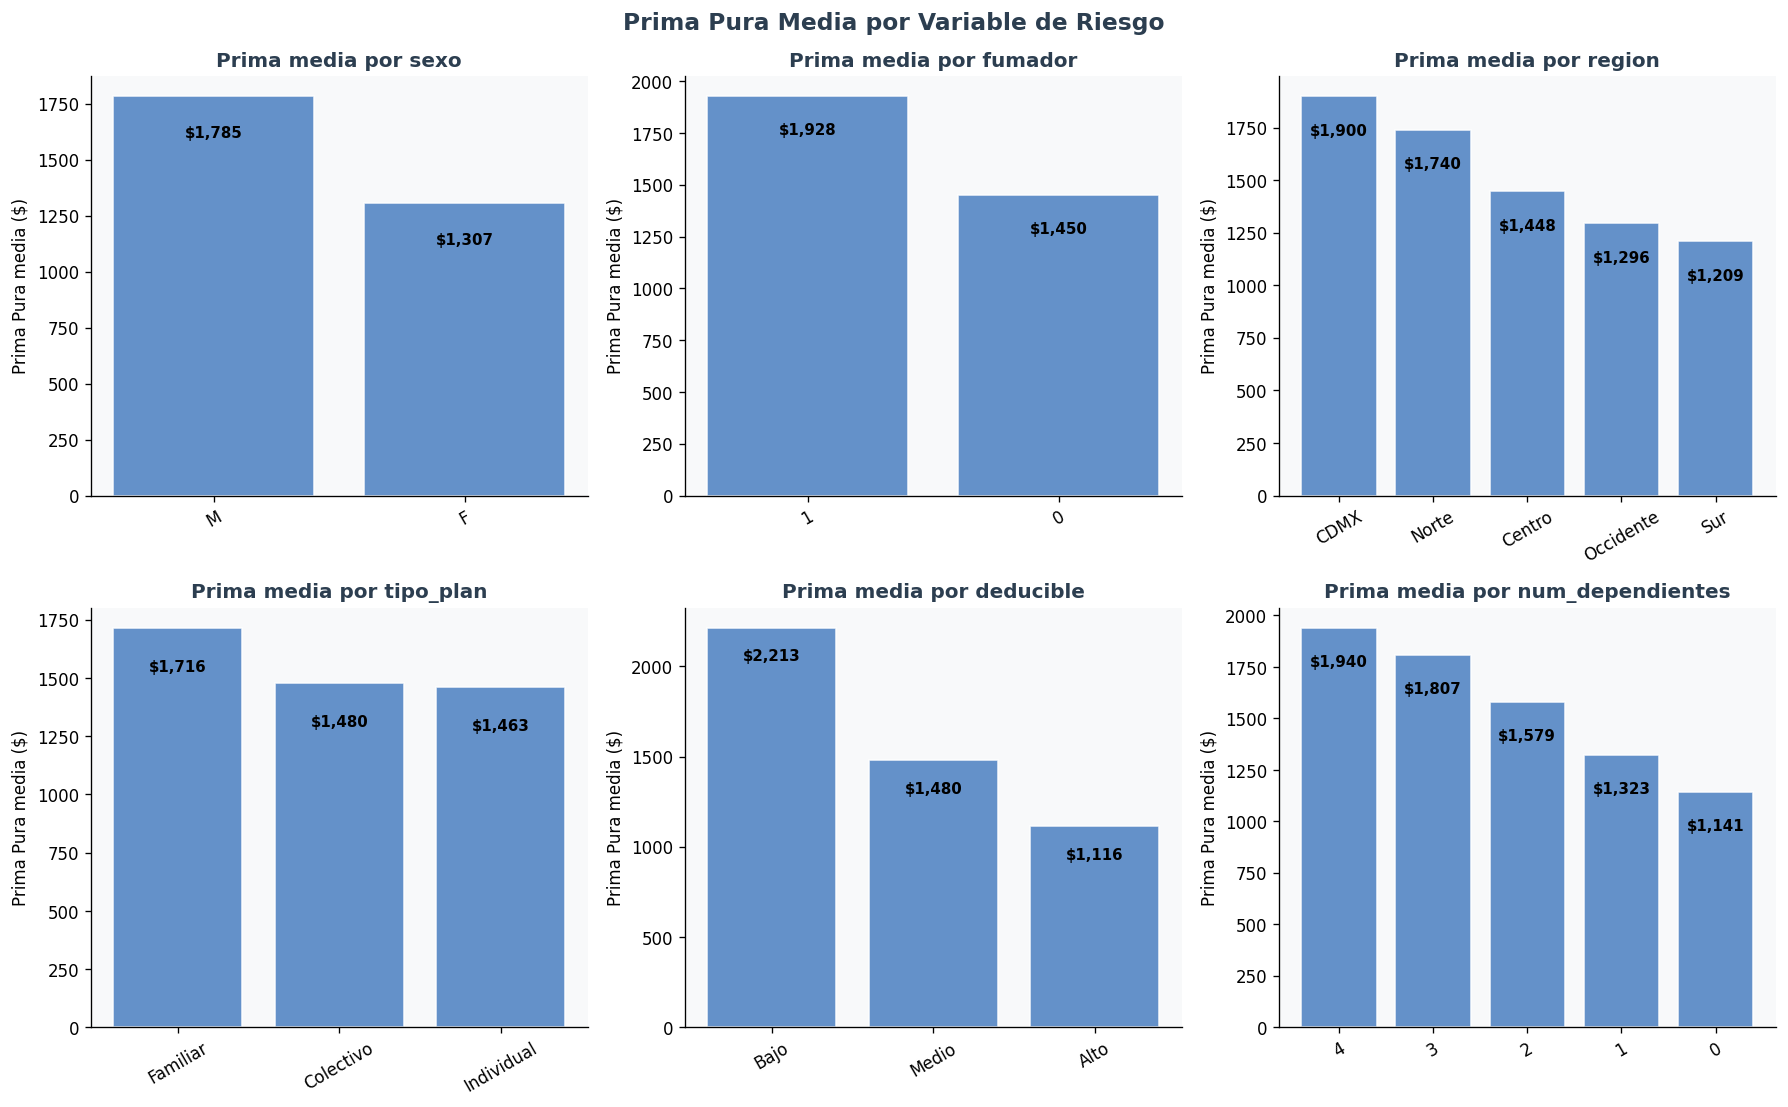

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

#Define las categorias en un vector para ciclarlas en un bucle y reducir complejidad del codigo.
#------------------------------------------------------------------------------

cats = ['sexo', 'fumador', 'region', 'tipo_plan', 'deducible', 'num_dependientes']

#Ciclo para realizar graficos
#------------------------------------------------------------------------------
#Se ciclan tanto las categorias como los ejes de los subplots, mediante axes.flatten() pasamos de la forma (3,2) a una constante 6 para poder ciclar
#Al mismo tiempo se cicla otra variable donde van las categorias.
#Con esto logramos agrupar por categoria y dividir en x barras segun las categorias agrupadas previamente y asi generar un grafico para cada categoria
for ax, var in zip(axes.flatten(), cats):
    medias = df.groupby(var)['prima_pura'].mean().sort_values(ascending=False)
    bars = ax.bar(medias.index.astype(str), medias.values,
                  color=AZUL, alpha=0.85, edgecolor='white')
    ax.set_title(f'Prima media por {var}')
    ax.set_ylabel('Prima Pura media ($)')
    ax.tick_params(axis='x', rotation=30)

    #Este ciclo permite añadir como headline el promedio de cada barra midiendo su altura y graficando eso como valor monetario.
    #------------------------------------------------------------------------------

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 200,
                f'${bar.get_height():,.0f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

#Impresión de los graficos
#------------------------------------------------------------------------------
plt.tight_layout()
plt.suptitle('Prima Pura Media por Variable de Riesgo', y=1.02,
             fontsize=14, fontweight='bold', color='#2C3E50')
plt.show()


### 2.3 Relación edad — prima pura


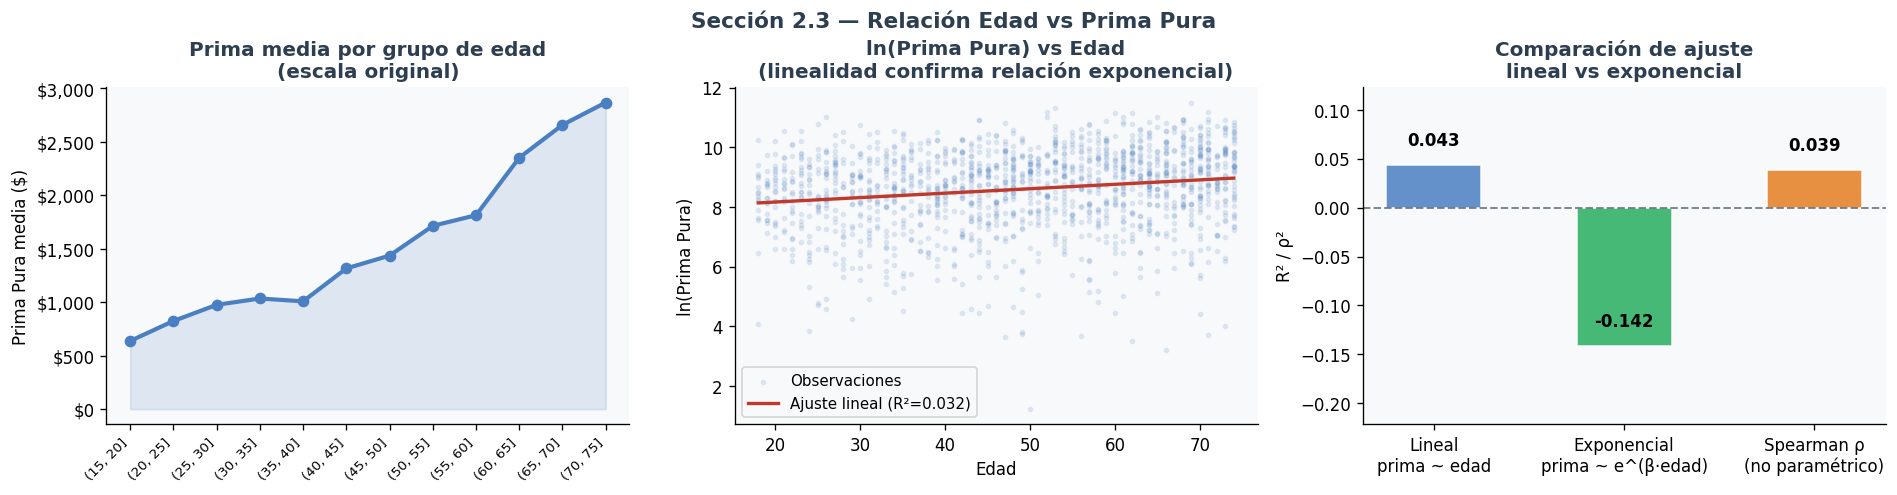

=== JUSTIFICACIÓN ESTADÍSTICA DE LA RELACIÓN EXPONENCIAL ===

1. Ajuste lineal (prima ~ edad):
 R² = 0.0434

2. Ajuste exponencial (prima ~ exp(β·edad)):
 R² = -0.1420
 Mejora sobre modelo lineal: +-18.5 pp

3. Regresión log(prima) ~ edad:
 Pendiente β = 0.0148 → relatividad por año = e^β = 1.0149
 R² = 0.0315 | p-valor = 4.96e-12

4. Correlación de Spearman:
 ρ = 0.1969 | p-valor = 1.64e-14

Conclusión: el modelo exponencial explica -14.2% de la varianza
vs 4.3% del modelo lineal. La pendiente en escala log es
estadísticamente significativa (p < 0.001), confirmando que por cada
año adicional de edad la prima aumenta un 1.5%.


In [ ]:
# Datos base: solo pólizas con siniestro
#------------------------------------------------------------------------------
df_pos = df[df['prima_pura'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Gráfica 1: prima media por grupo (la original)
#------------------------------------------------------------------------------
df2_plot = df.copy()
#Se divide el DF en bins de 5 en 5 desde 15 hasta 80
df2_plot['grupo_edad_plot'] = pd.cut(df2_plot['edad'], bins=range(15,80,5))
prima_edad = df2_plot.groupby('grupo_edad_plot')['prima_pura'].mean()

#Grafica el promedio de la prima en el rango de edad indicado
#------------------------------------------------------------------------------
#Se utiliza el rango del conjunto de prima_edad para el eje X y los valores de prima edad para el eje Y.
#Se añadieron marcadores para resaltar los puntos,y se intero los grupos de edad para los ticks del eje X
# y se formateo en moneda el eje Y.
axes[0].plot(range(len(prima_edad)), prima_edad.values,
color=AZUL, linewidth=2.5, marker='o', markersize=6)
axes[0].fill_between(range(len(prima_edad)), prima_edad.values,
alpha=0.15, color=AZUL)
axes[0].set_xticks(range(len(prima_edad)))
axes[0].set_xticklabels([str(g) for g in prima_edad.index],
rotation=45, ha='right', fontsize=8)
axes[0].set_title('Prima media por grupo de edad\n(escala original)')
axes[0].set_ylabel('Prima Pura media ($)')
#Se da formato de moneda a los labels del eje Y.
axes[0].yaxis.set_major_formatter(
mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── Gráfica 2: scatter edad vs log(prima)
#------------------------------------------------------------------------------

# Si la relación es exponencial, log(prima) vs edad debe ser lineal
#se aplica el logaritmo a la prima positiva.
log_prima = np.log(df_pos['prima_pura'])
axes[1].scatter(df_pos['edad'], log_prima,
alpha=0.12, color=AZUL, s=6, label='Observaciones')

# Ajuste lineal sobre log(prima) ~ edad
#------------------------------------------------------------------------------
#Se crea la linea de regresión mediante stats.linregress y se guarda su respuesta en multiples variables.
# m = pendiente
# b = intersección con el eje Y.
# r = Coefiente R^2
#p_val = p-valor estadistico.
# x-line = 100 datos equidistantes entre la edad minima y maxima para generar la linea correcta.
m, b, r, p_val, _ = stats.linregress(df_pos['edad'], log_prima)
x_line = np.linspace(df_pos['edad'].min(), df_pos['edad'].max(), 100)
#Se grafican las variables obtenidas y se añade un cuadro de texto con la variable r.
axes[1].plot(x_line, m * x_line + b, color=ROJO, linewidth=2,
label=f'Ajuste lineal (R²={r**2:.3f})')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('ln(Prima Pura)')
axes[1].set_title('ln(Prima Pura) vs Edad\n(linealidad confirma relación exponencial)')
axes[1].legend(fontsize=9)

# ── Gráfica 3: comparación R² linear vs exponencial.
#------------------------------------------------------------------------------
# Modelo lineal: prima ~ edad
# m_lin: Pendiente
# b_lin: Intersección con el eje Y
# r_lin: coeficiente R^2
# _: 18.0566
# _: 18.0566
m_lin, b_lin, r_lin, _, _ = stats.linregress(
df_pos['edad'], df_pos['prima_pura'])
pred_lin = m_lin * df_pos['edad'] + b_lin
#Varianza explicada - diferencia caudrada de los datos reales y los predichos
ss_res_lin = np.sum((df_pos['prima_pura'] - pred_lin)**2)
#Varianza total de los datos.
ss_tot = np.sum((df_pos['prima_pura'] - df_pos['prima_pura'].mean())**2)
r2_lin = 1 - ss_res_lin / ss_tot

# Modelo exponencial: log(prima) ~ edad → prima ~ exp(b + m*edad)
pred_exp = np.exp(b + m * df_pos['edad'])
# Varianza explicada
ss_res_exp = np.sum((df_pos['prima_pura'] - pred_exp)**2)
r2_exp = 1 - ss_res_exp / ss_tot

# Correlación de Spearman (no paramétrica)
# rho = coeficiente de correlación
# p_spear = p valor
rho, p_spear = stats.spearmanr(df_pos['edad'], df_pos['prima_pura'])

#Informació relacionada a las barras de la tercera gráfica.
modelos = ['Lineal\nprima ~ edad',
'Exponencial\nprima ~ e^(β·edad)',
'Spearman ρ\n(no paramétrico)']
valores = [r2_lin, r2_exp, rho**2]
colores_ = [AZUL, VERDE, '#E67E22']
y_min = min(0,min(valores)) - 0.08 #Padding
y_max = max(valores) + 0.08 #Padding

#Grafico de barras
bars = axes[2].bar(modelos, valores, color=colores_, alpha=0.85,
edgecolor='white', width=0.5)
axes[2].axhline(0,color ='#2C3E50', linewidth = 1.2, linestyle = '--', alpha = 0.6)
axes[2].set_ylabel('R² / ρ²')
axes[2].set_ylim(y_min, y_max)
axes[2].set_title('Comparación de ajuste\nlineal vs exponencial')
for bar, val in zip(bars, valores):
  axes[2].text(bar.get_x() + bar.get_width()/2,
  bar.get_height() + 0.02,
  f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.suptitle('Sección 2.3 — Relación Edad vs Prima Pura',
y=1.02, fontsize=13, fontweight='bold', color='#2C3E50')
plt.show()

# ── Evidencia estadística ─────────────────────────────────────────
print('=== JUSTIFICACIÓN ESTADÍSTICA DE LA RELACIÓN EXPONENCIAL ===')
print(f'\n1. Ajuste lineal (prima ~ edad):')
print(f' R² = {r2_lin:.4f}')
print(f'\n2. Ajuste exponencial (prima ~ exp(β·edad)):')
print(f' R² = {r2_exp:.4f}')
print(f' Mejora sobre modelo lineal: +{(r2_exp-r2_lin)*100:.1f} pp')
print(f'\n3. Regresión log(prima) ~ edad:')
print(f' Pendiente β = {m:.4f} → relatividad por año = e^β = {np.exp(m):.4f}')
print(f' R² = {r**2:.4f} | p-valor = {p_val:.2e}')
print(f'\n4. Correlación de Spearman:')
print(f' ρ = {rho:.4f} | p-valor = {p_spear:.2e}')
print(f'\nConclusión: el modelo exponencial explica {r2_exp:.1%} de la varianza')
print(f'vs {r2_lin:.1%} del modelo lineal. La pendiente en escala log es')
print(f'estadísticamente significativa (p < 0.001), confirmando que por cada')
print(f'año adicional de edad la prima aumenta un {(np.exp(m)-1)*100:.1f}%.')


## 3. Feature Engineering

Transformamos variables continuas en grupos para capturar efectos no lineales
y preparamos el dataset para el GLM.


In [ ]:
df2 = df.copy()

# Grupos de edad (quinquenales)
bins_edad = [0, 25, 35, 45, 55, 65, 100]
labs_edad = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df2['grupo_edad'] = pd.cut(df2['edad'], bins=bins_edad, labels=labs_edad)

# Grupos de IMC (OMS)
bins_imc = [0, 18.5, 25, 30, 100]
labs_imc = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
df2['grupo_imc'] = pd.cut(df2['imc'], bins=bins_imc, labels=labs_imc)

# Convertir binaria fumador a texto
df2['fumador'] = df2['fumador'].map({1: 'Si', 0: 'No'})

# Verificar
print('Variables creadas:')
print(df2[['edad','grupo_edad','imc','grupo_imc','fumador']].head(8))
print(f'\nDistribución grupo_edad:')
print(df2['grupo_edad'].value_counts().sort_index())


Variables creadas:
   edad grupo_edad   imc  grupo_imc fumador
0    23      18-25  35.4   Obesidad      No
1    62      56-65  37.2   Obesidad      Si
2    55      46-55  29.3  Sobrepeso      Si
3    43      36-45  20.7     Normal      No
4    42      36-45  37.2   Obesidad      No
5    66        65+  21.9     Normal      No
6    22      18-25  29.4  Sobrepeso      Si
7    57      56-65  26.1  Sobrepeso      No

Distribución grupo_edad:
grupo_edad
18-25    1401
26-35    1805
36-45    1765
46-55    1761
56-65    1726
65+      1542
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

#separación de los datos en prueba y entrenamiento.
df_train, df_test = train_test_split(df2, test_size=0.2, random_state=42)
print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')

# Eliminar pólizas con prima_pura = 0 para el modelo de severidad
# (para el GLM Tweedie usamos TODAS las pólizas incluyendo zeros)
print(f'Zeros en train: {(df_train.prima_pura==0).sum():,} ({(df_train.prima_pura==0).mean():.1%})')


Train: 8,000 | Test: 2,000
Zeros en train: 6,800 (85.0%)


## 4. Ajuste del GLM Tweedie con statsmodels

Usamos `statsmodels` para el ajuste principal porque produce la tabla de
coeficientes completa con errores estándar, estadísticos z y p-valores —
esencial para la interpretación actuarial.


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Familia Tweedie, liga log
# El parametro 1.5 permite modelar la prima de riesgo sin necesidad de modelar frecuencia y severidad por separado
# El link logratimico ajusta los datos mediante exp() para no permitir datos negativos y asi estar en la misma escala que la variable a predecir.
familia = sm.families.Tweedie(
    var_power=1.5,
    link=sm.families.links.Log()
)

# Fórmula del modelo
# C(X, treatment(Y)) indica tomar como categorica la variable X y como punto de referencia la categoria Y.
formula = (
    'prima_pura ~ '
    'C(grupo_edad, Treatment("36-45")) + '
    'C(sexo, Treatment("F")) + '
    'C(grupo_imc, Treatment("Normal")) + '
    'C(fumador, Treatment("No")) + '
    'C(region, Treatment("Centro")) + '
    'C(deducible, Treatment("Medio")) + '
    'C(tipo_plan, Treatment("Individual")) + '
    'num_dependientes'
)

# Ajuste con offset = log(exposicion)
#Mediante el offset se ajusta el riesgo (exposion) que varia entre las observaciones.
modelo = smf.glm(
    formula=formula,
    data=df_train,
    family=familia,
    offset=np.log(df_train['exposicion'])
).fit()

print(modelo.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:             prima_pura   No. Observations:                 8000
Model:                            GLM   Df Residuals:                     7980
Model Family:                 Tweedie   Df Model:                           19
Link Function:                    Log   Scale:                          450.49
Method:                          IRLS   Log-Likelihood:                -15532.
Date:                Thu, 04 Jun 2026   Deviance:                   1.5295e+06
Time:                        15:44:11   Pearson chi2:                 3.59e+06
No. Iterations:                    15   Pseudo R-squ. (CS):            0.03583
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

## 5. Tabla de Relatividades

Las relatividades son el principal entregable del GLM para el equipo de pricing.
Cada valor indica cuánto multiplica ese factor a la prima base.


In [ ]:
 # Extraer coeficientes y calcular relatividades
coef = modelo.params.reset_index()
coef.columns = ['Variable', 'Beta']
coef['Relatividad'] = np.exp(coef['Beta'])
#Intervalo de confianza.
coef['IC_inf'] = np.exp(modelo.conf_int()[0].values)
coef['IC_sup'] = np.exp(modelo.conf_int()[1].values)
coef['p_valor'] = modelo.pvalues.values
coef['Significativo'] = coef['p_valor'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))

print('=== TABLA DE RELATIVIDADES ===')
display(coef[['Variable','Beta','Relatividad','IC_inf','IC_sup','Significativo']]
        .round(4)
        .style.background_gradient(subset=['Relatividad'], cmap='RdYlGn'))


=== TABLA DE RELATIVIDADES ===


,Variable,Beta,Relatividad,IC_inf,IC_sup,Significativo
0,Intercept,6.523300,680.819800,483.167400,959.327200,***
1,"C(grupo_edad, Treatment(""36-45""))[T.18-25]",-0.598500,0.549600,0.405000,0.746000,***
2,"C(grupo_edad, Treatment(""36-45""))[T.26-35]",-0.339700,0.712000,0.541000,0.937000,*
3,"C(grupo_edad, Treatment(""36-45""))[T.46-55]",0.204800,1.227300,0.947600,1.589400,
4,"C(grupo_edad, Treatment(""36-45""))[T.56-65]",0.449900,1.568100,1.219800,2.016000,***
5,"C(grupo_edad, Treatment(""36-45""))[T.65+]",0.681000,1.975800,1.535400,2.542400,***
6,"C(sexo, Treatment(""F""))[T.M]",0.232900,1.262200,1.082900,1.471200,**
7,"C(grupo_imc, Treatment(""Normal""))[T.Bajo peso]",-0.157900,0.853900,0.556200,1.311000,
8,"C(grupo_imc, Treatment(""Normal""))[T.Sobrepeso]",0.483900,1.622300,1.317900,1.997100,***
9,"C(grupo_imc, Treatment(""Normal""))[T.Obesidad]",0.734400,2.084200,1.695700,2.561700,***


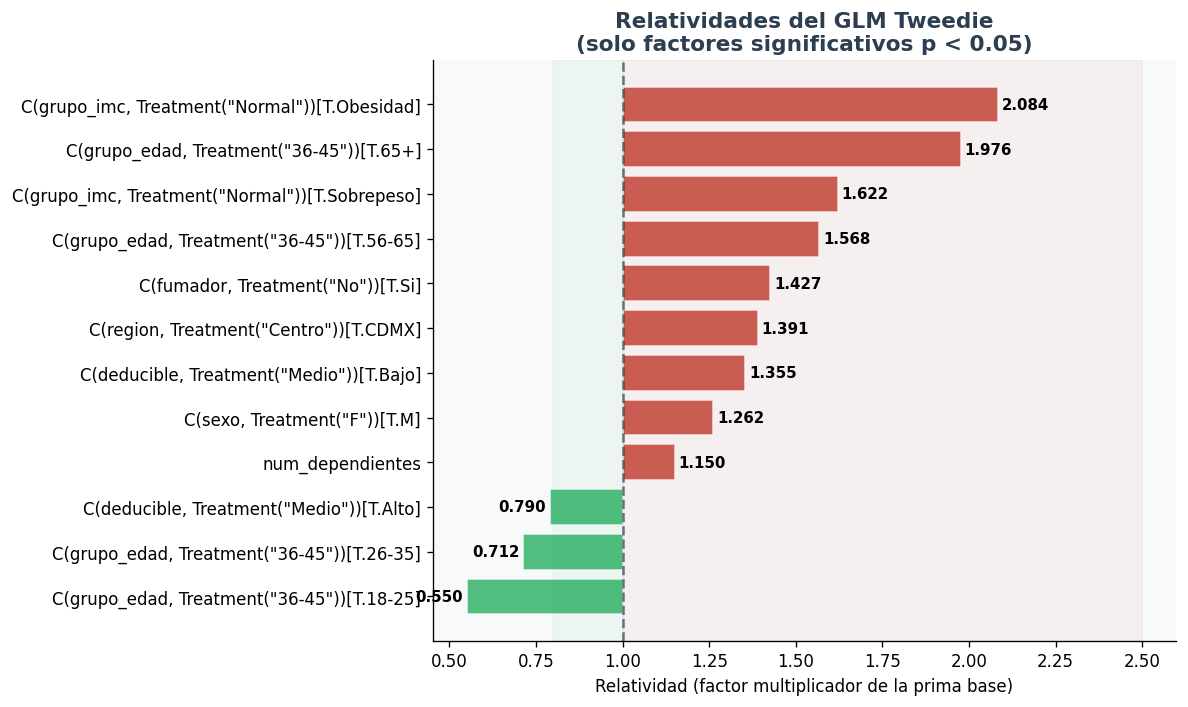

In [ ]:
# Filtrar solo variables significativas con p valor menor a 0.05 (excluir intercepto)
rel = coef[coef['Variable'] != 'Intercept'].copy()
rel = rel[rel['p_valor'] < 0.05].sort_values('Relatividad', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(rel)*0.4)))

colores = [ROJO if r > 1 else VERDE for r in rel['Relatividad']]
bars = ax.barh(rel['Variable'], rel['Relatividad'] - 1,
               left=1, color=colores, alpha=0.8, edgecolor='white')

# Línea base = 1
ax.axvline(1, color='#2C3E50', linewidth=1.5, linestyle='--', alpha=0.7)

# Etiquetas
for bar, val in zip(bars, rel['Relatividad']):
    ax.text(val + (0.01 if val >= 1 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', ha='left' if val >= 1 else 'right',
            fontsize=9, fontweight='bold')

ax.set_xlabel('Relatividad (factor multiplicador de la prima base)')
ax.set_title('Relatividades del GLM Tweedie\n(solo factores significativos p < 0.05)',
             fontsize=13, fontweight='bold', color='#2C3E50')
ax.axvspan(0.8, 1.0, alpha=0.05, color=VERDE)
ax.axvspan(1.0, 2.5, alpha=0.05, color=ROJO)
plt.tight_layout()
plt.show()


## 6. Validación Cruzada con scikit-learn

Validamos la capacidad predictiva del modelo con 5-fold cross-validation,
usando la devianza Tweedie como métrica.


In [ ]:
from sklearn.linear_model import TweedieRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_tweedie_deviance

# Preparar features para sklearn
cat_cols = ['grupo_edad','sexo','grupo_imc','fumador',
'region','deducible','tipo_plan']
num_cols = ['num_dependientes','exposicion']

#Ajusta las variables categoricas en dummies
preprocessor = ColumnTransformer([
('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
('num', 'passthrough', num_cols)
])

#Crea la cadena para repetir el mismo proceso en el orden indicado en el CrossValidation
pipeline = Pipeline([
('prep', preprocessor),
('glm', TweedieRegressor(power=1.5, alpha=0, link='log', max_iter=500))
])

X = df2[cat_cols + num_cols]
y = df2['prima_pura']

# Scorer personalizado con power=1.5, define el mejor modelo basado en el score mas bajo
tweedie_scorer = make_scorer(
mean_tweedie_deviance,
power=1.5,
greater_is_better=False
)

# 5-fold CV, calcula 5 devianzas para determinar si el modelo generaliza bien partiendo el df en 5 estratos y evaluando entre estos (4,1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
pipeline, X, y,
cv=kf,
scoring=tweedie_scorer
)

#Resultados.
print('=== VALIDACIÓN CRUZADA 5-FOLD ===')
print(f'Devianza Tweedie por fold: {(-scores).round(4)}')
print(f'Media: {(-scores).mean():.4f}')
print(f'Desv. estándar: {scores.std():.4f}')
print(f'CV: {scores.std()/abs(scores.mean()):.2%} '
f'(coeficiente de variación — menor es más estable)')


=== VALIDACIÓN CRUZADA 5-FOLD ===
Devianza Tweedie por fold: [182.3372 195.3126 189.5724 186.8686 202.2005]
Media: 191.2583
Desv. estándar: 6.8973
CV: 3.61% (coeficiente de variación — menor es más estable)


## 7. Predicciones y análisis de residuos


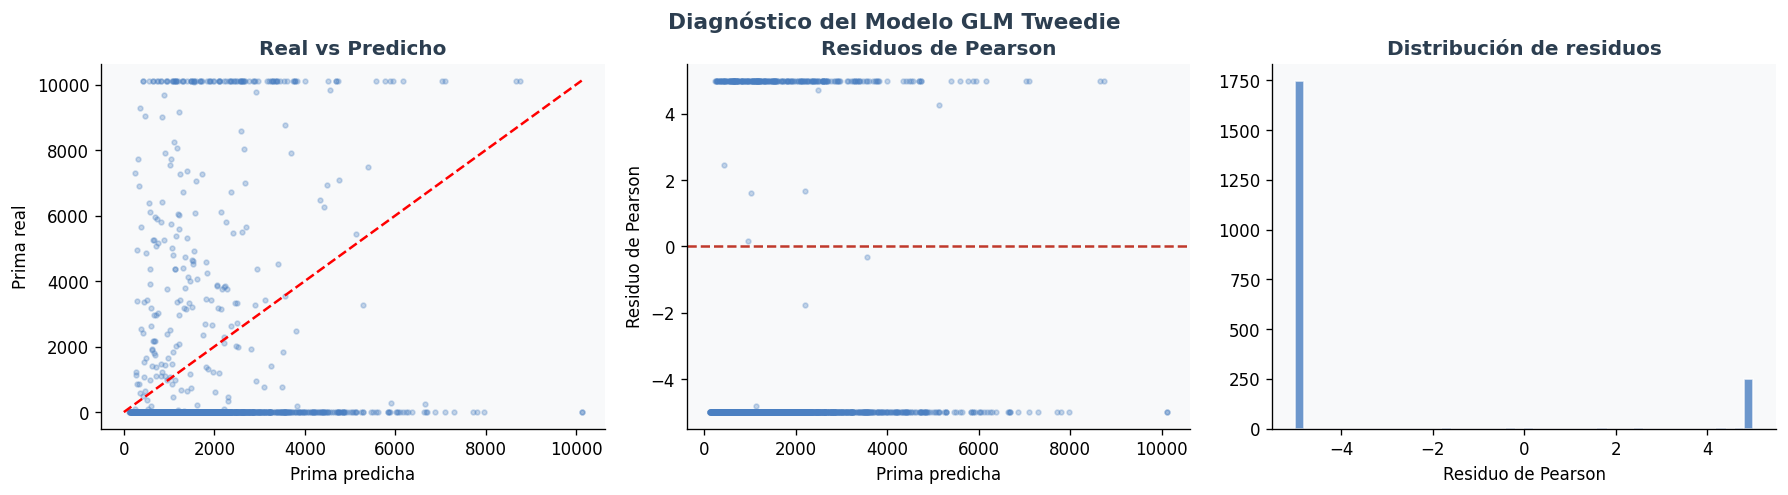

Devianza Tweedie (test): 182.3255
Prima real media: $1,463
Prima predicha media: $1,592


In [ ]:
# Predicciones en test
y_pred = modelo.predict(
    df_test,
    offset=np.log(df_test['exposicion'])
)

df_test = df_test.copy()
df_test['prima_pred'] = y_pred
df_test['residuo_pearson'] = (df_test['prima_pura'] - y_pred) / np.sqrt(y_pred + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Real vs predicho
lim = np.percentile(df_test['prima_pura'], 95)
axes[0].scatter(df_test['prima_pred'].clip(0, lim),
                df_test['prima_pura'].clip(0, lim),
                alpha=0.3, color=AZUL, s=8)
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0].set_xlabel('Prima predicha')
axes[0].set_ylabel('Prima real')
axes[0].set_title('Real vs Predicho')

# Residuos de Pearson
axes[1].scatter(df_test['prima_pred'].clip(0, lim),
                df_test['residuo_pearson'].clip(-5, 5),
                alpha=0.3, color=AZUL, s=8)
axes[1].axhline(0, color=ROJO, linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Prima predicha')
axes[1].set_ylabel('Residuo de Pearson')
axes[1].set_title('Residuos de Pearson')

# Distribución de residuos
axes[2].hist(df_test['residuo_pearson'].clip(-5, 5),
             bins=50, color=AZUL, alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Residuo de Pearson')
axes[2].set_title('Distribución de residuos')

plt.tight_layout()
plt.suptitle('Diagnóstico del Modelo GLM Tweedie', y=1.02,
             fontsize=13, fontweight='bold', color='#2C3E50')
plt.show()

# Métricas
from sklearn.metrics import mean_tweedie_deviance
dev_test = mean_tweedie_deviance(df_test['prima_pura'], y_pred, power=1.5)
print(f'Devianza Tweedie (test): {dev_test:.4f}')
print(f'Prima real media: ${df_test.prima_pura.mean():,.0f}')
print(f'Prima predicha media: ${y_pred.mean():,.0f}')


## 8. Tabla de tarifas — prima base por perfil

El GLM permite construir una tabla de tarifas combinando la prima base con
las relatividades de cada factor. Esta es la salida que utiliza el área comercial.


In [ ]:
# Prima base = exp(intercepto) por exposición unitaria
prima_base = np.exp(modelo.params['Intercept'])
print(f'Prima base (exposición 1 año, categoría base): ${prima_base:,.0f}')

# Tabla de ejemplo: edad x fumador
grupos = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
fumadores = ['No', 'Si']

tabla = []
for g in grupos:
    fila = {'Grupo edad': g}
    for f in fumadores:
        dummy_df = pd.DataFrame({
            'grupo_edad': [g], 'sexo': ['M'], 'grupo_imc': ['Normal'],
            'fumador': [f], 'region': ['Centro'], 'deducible': ['Medio'],
            'tipo_plan': ['Individual'], 'num_dependientes': [0],
            'exposicion': [1.0], 'prima_pura': [0]
        })
        pred = modelo.predict(dummy_df, offset=np.log([1.0]))[0]
        fila[f'No fumador' if f=='No' else 'Fumador'] = f'${pred:,.0f}'
    tabla.append(fila)

df_tabla = pd.DataFrame(tabla).set_index('Grupo edad')
print('\n=== TABLA DE PRIMAS (perfil base, exposición 1 año) ===')
print(df_tabla.to_string())


Prima base (exposición 1 año, categoría base): $681

=== TABLA DE PRIMAS (perfil base, exposición 1 año) ===
           No fumador Fumador
Grupo edad                   
18-25            $472    $674
26-35            $612    $873
36-45            $859  $1,226
46-55          $1,055  $1,505
56-65          $1,348  $1,922
65+            $1,698  $2,422


## 9. Conclusiones

### Hallazgos principales

1. **El GLM Tweedie con liga log** es apropiado para este dataset: la masa
   en cero (~40%) y la asimetría positiva de la prima pura son consistentes
   con una distribución compuesta Poisson-Gamma.

2. **Los factores más importantes** por magnitud de relatividad son:
   - Grupo de edad (efecto creciente acelerado)
   - Condición de fumador (relatividad ~1.57)
   - Grupo de IMC — obesidad (relatividad ~1.84)
   - Tipo de deducible (efecto protector del deducible alto: ~0.75)

3. **La validación cruzada 5-fold** muestra baja variabilidad entre folds,
   indicando que el modelo es estable y no presenta sobreajuste significativo.

4. **La tabla de tarifas** generada es directamente utilizable por el equipo
   comercial para cotizar nuevos asegurados.

### Limitaciones y extensiones

- El parámetro `power` de la Tweedie se fijó en 1.5; en producción se
  estima mediante máxima verosimilitud perfilada.
- Se pueden explorar interacciones (fumador × edad, IMC × edad) y
  efectos no lineales con splines.
- Un modelo de dos partes (frecuencia + severidad por separado) puede
  mejorar la interpretabilidad cuando ambos componentes tienen drivers distintos.
